In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics

import esc_fresnel.efc as efc

dm_choice = 2



In [67]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

if dm_choice == 1:
    dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')
elif dm_choice == 2:
    dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat_48.fits')
elif dm_choice == 3:
    dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat_64.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe
    # wfes[optic].opd /= 2

# dm_map = poppy.FITSOpticalElement(
#     opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat.fits'), 
#     opdunits='meters',
#     name=f'dm_wfe',
#     pixelscale='SCALE',
#     planetype=poppy.poppy_core.PlaneType.intermediate,
# )
# dm_map.opd *= 2

# dm_map = poppy.FITSOpticalElement(
#     opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
#     opdunits='meters',
#     name=f'dm_wfe',
#     planetype=poppy.poppy_core.PlaneType.intermediate,
# )

# wfes.update({'DM':dm_map})

0


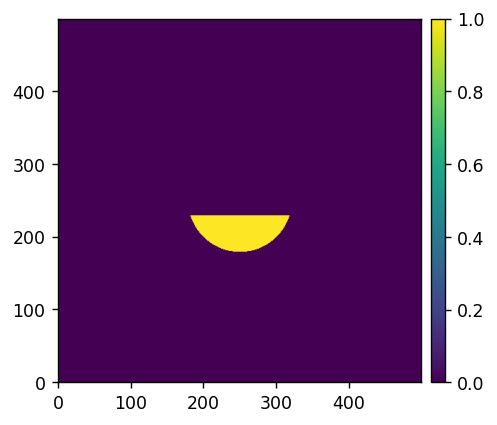

1


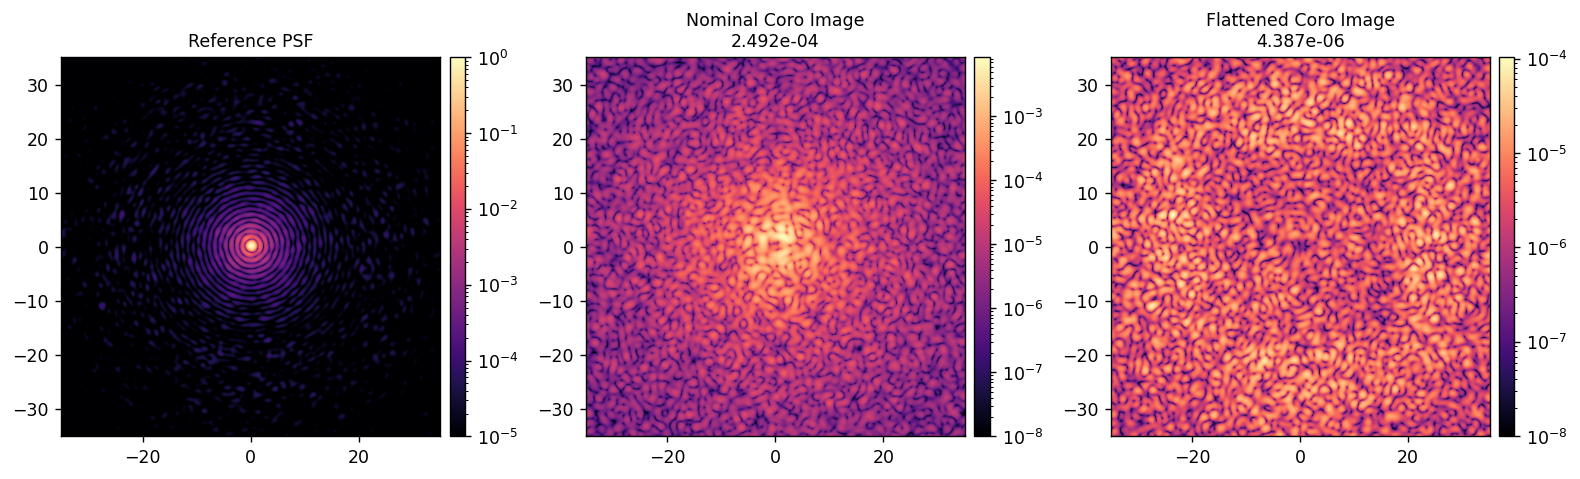

In [68]:
reload(esc)
M = esc.single(
    dm_choice=dm_choice,
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 500

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
M.zero_dm()
coro_im_0 = M.snap()

M.reset_dm()
coro_im_flat = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_0, coro_im_flat],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Nominal Coro Image\n{contrast_0:.3e}',
            f'Flattened Coro Image\n{contrast_flat:.3e}',],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [61]:
M.Nact

48

In [60]:
M.DM.dm_channels.shape

(10, 48, 48)

In [34]:
reload(efc)

jac = efc.compute_jacobian(
    M, 
    1e-9,
    coro_mask, 
    plot=True,
)

In [6]:
calib_data = {
    'jacobian':jac,
}

utils.save_pickle(esc_fresnel.path/'wfe-maps'/wfe_dir/'efc_mono_calib_64.pkl', calib_data)

NameError: name 'jac' is not defined

In [69]:
# calib_data = utils.load_pickle( esc_fresnel.path/'wfe-maps'/wfe_dir/'efc_mono_calib.pkl' )
calib_data = utils.load_pickle( esc_fresnel.path/'wfe-maps'/wfe_dir/'efc_mono_calib_48.pkl' )
# calib_data = utils.load_pickle( esc_fresnel.path/'wfe-maps'/wfe_dir/'efc_mono_calib_64.pkl' )
jac = calib_data['jacobian']

In [70]:
reload(utils)
cm20 = utils.beta_reg(jac, -2)
cm25 = utils.beta_reg(jac, -2.5)
# cm30 = utils.beta_reg(jac, -3)
# cm35 = utils.beta_reg(jac, -3.5)
# cm40 = utils.beta_reg(jac, -4)
cm45 = utils.beta_reg(jac, -4.5)
cm50 = utils.beta_reg(jac, -5)

In [71]:
M.reset_dm()
efc_data = {
    'images':[coro_im_flat],
    'contrasts':[contrast_flat],
    'commands':[],
    'efields':[],
    'del_commands':[],
    'pixelscale':M.camsci_pxscl_lamDc,
    'control_mask':coro_mask, 
}

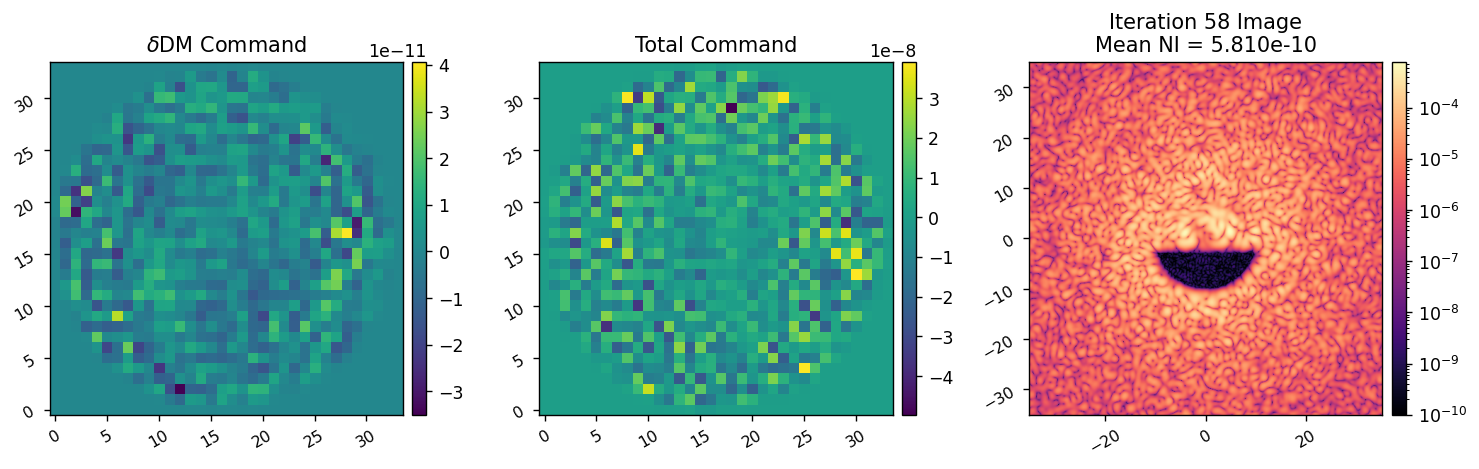

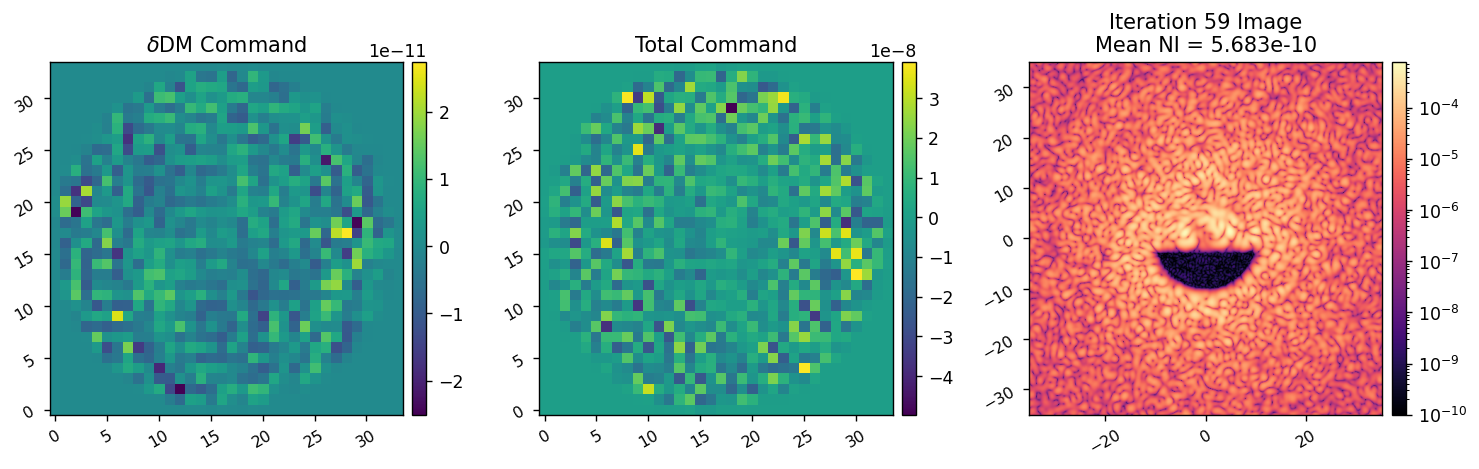

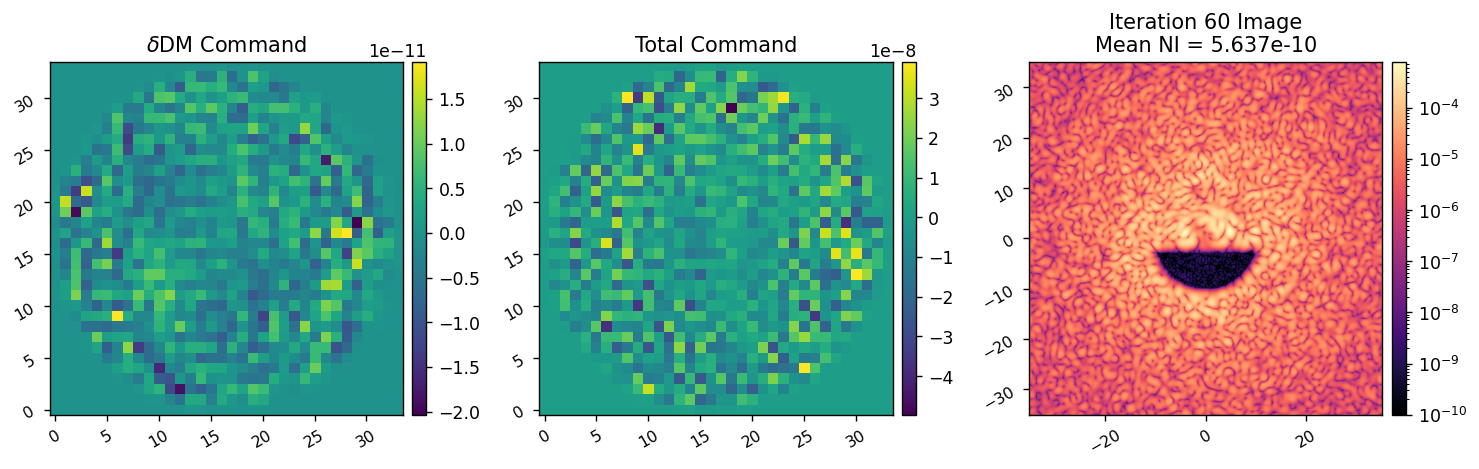

In [62]:
reload(efc)

efc_data = efc.run(
    M,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    coro_mask,
    M.dm_mask,
    efc_data,
    num_iterations=3,
    plot=1,
    vmin=1e-10,
)

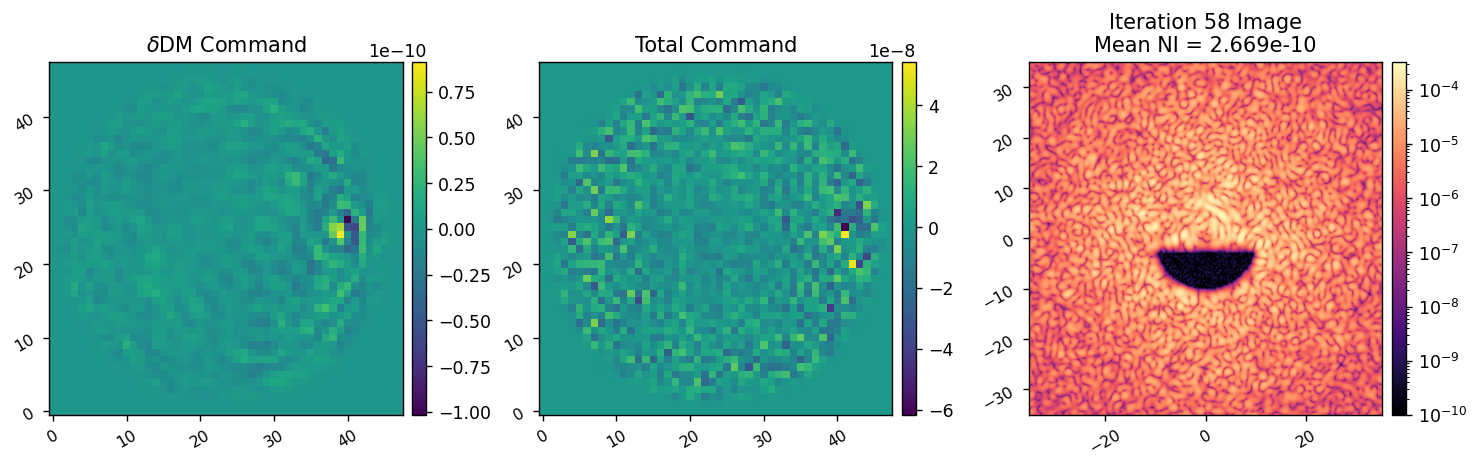

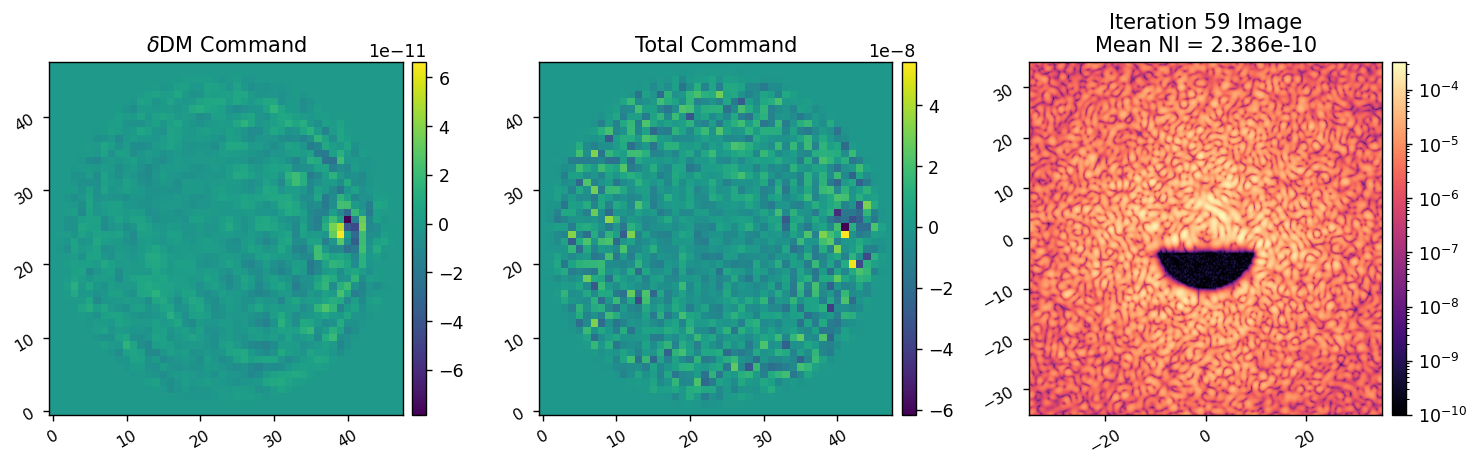

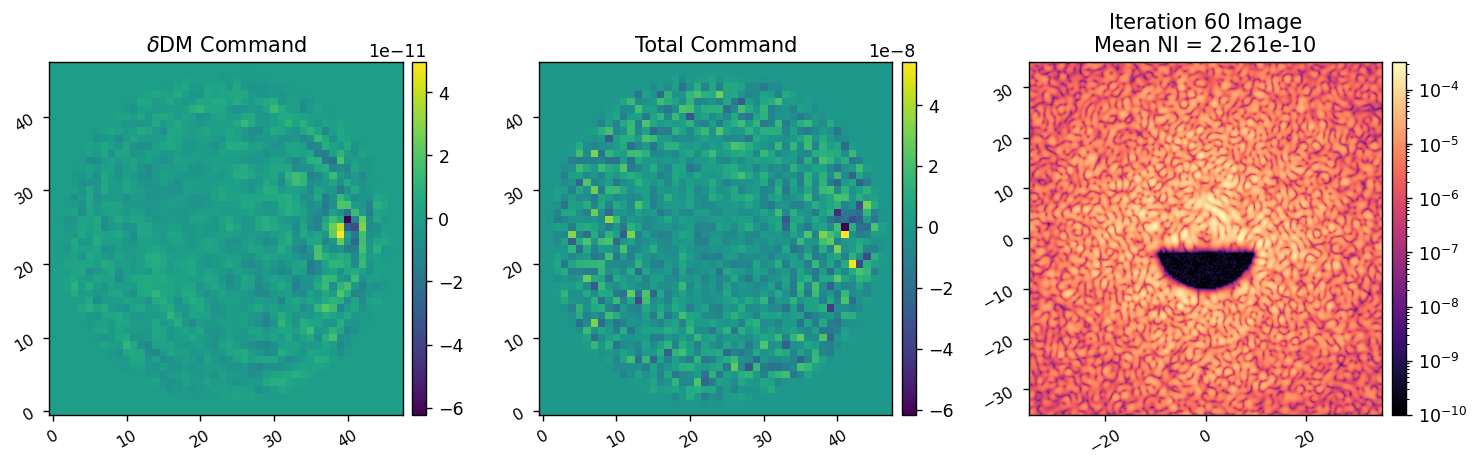

In [91]:
reload(efc)

efc_data = efc.run(
    M,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    coro_mask,
    M.dm_mask,
    efc_data,
    num_iterations=3,
    plot=1,
    vmin=1e-10,
)

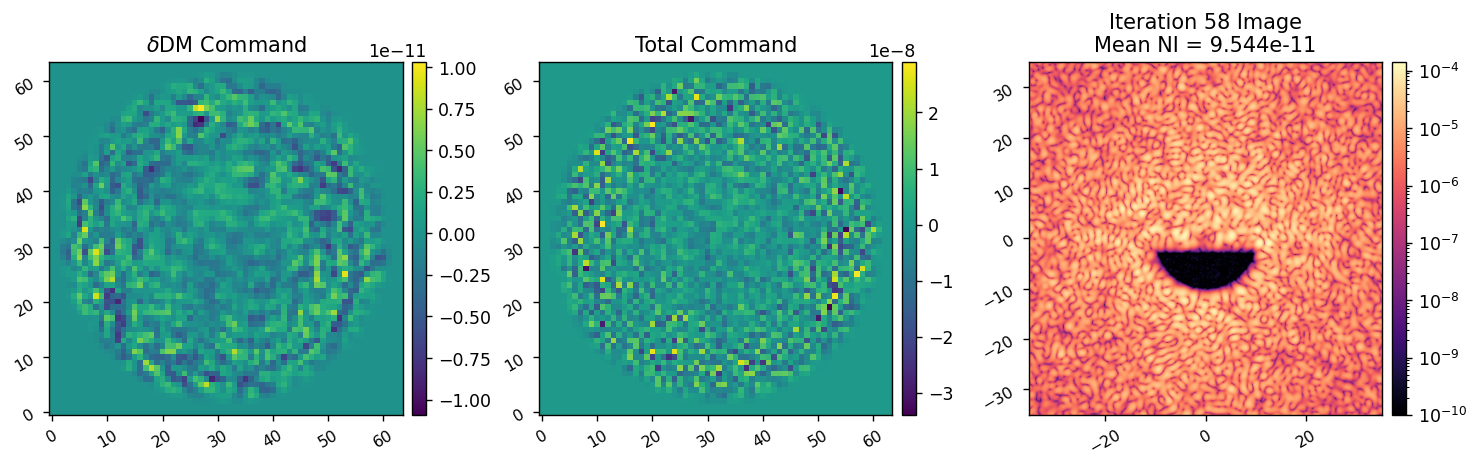

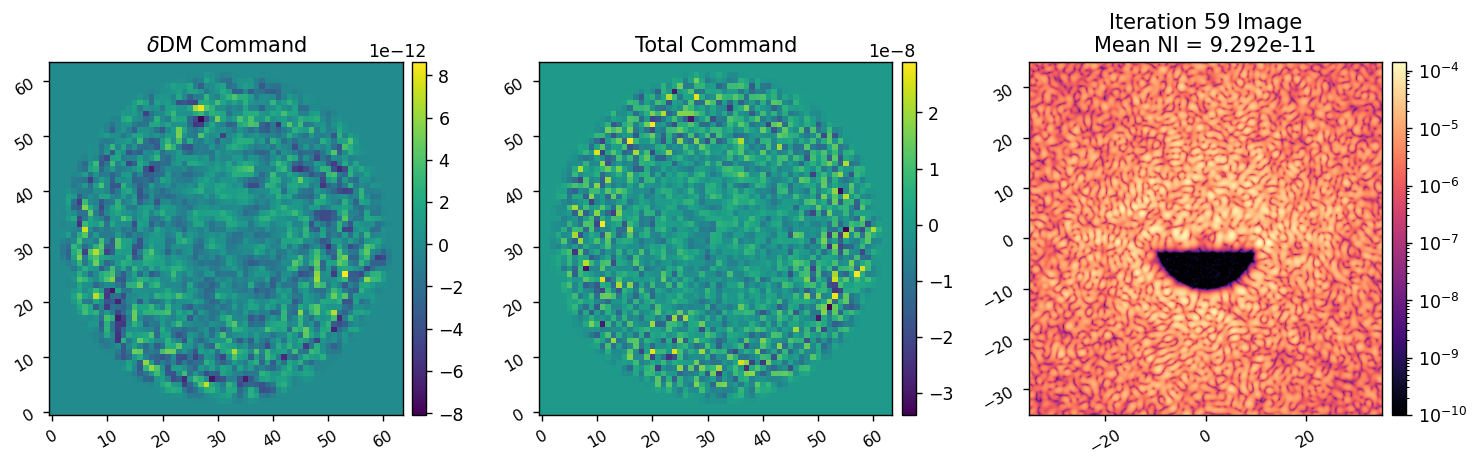

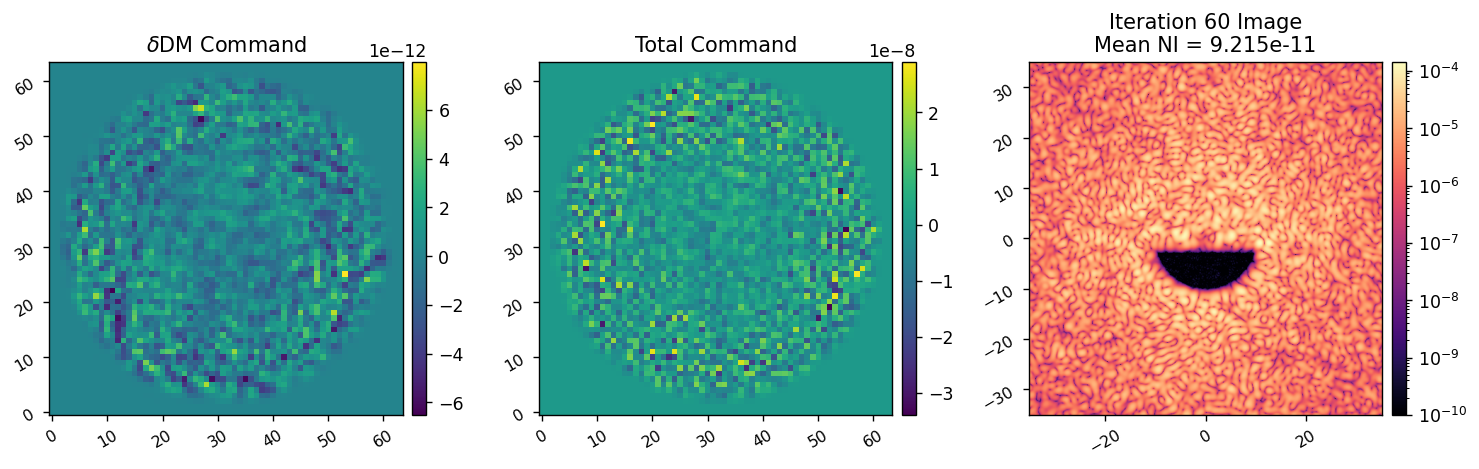

In [29]:
reload(efc)

efc_data = efc.run(
    M,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    coro_mask,
    M.dm_mask,
    efc_data,
    num_iterations=3,
    plot=1,
    vmin=1e-10,
)

In [30]:
utils.save_pickle(esc_fresnel.path/'data'/'esc_fresnel_efc_64_data.pkl', efc_data)

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/data/esc_fresnel_efc_64_data.pkl


In [51]:
efc_data['contrasts'][6]

array(1.75760808e-08)

In [52]:
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-8.fits', efc_data['commands'][7])
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-9.fits', efc_data['commands'][15])
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_6e-10.fits', efc_data['commands'][-1])

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_1e-8.fits
Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_1e-9.fits
Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_6e-10.fits


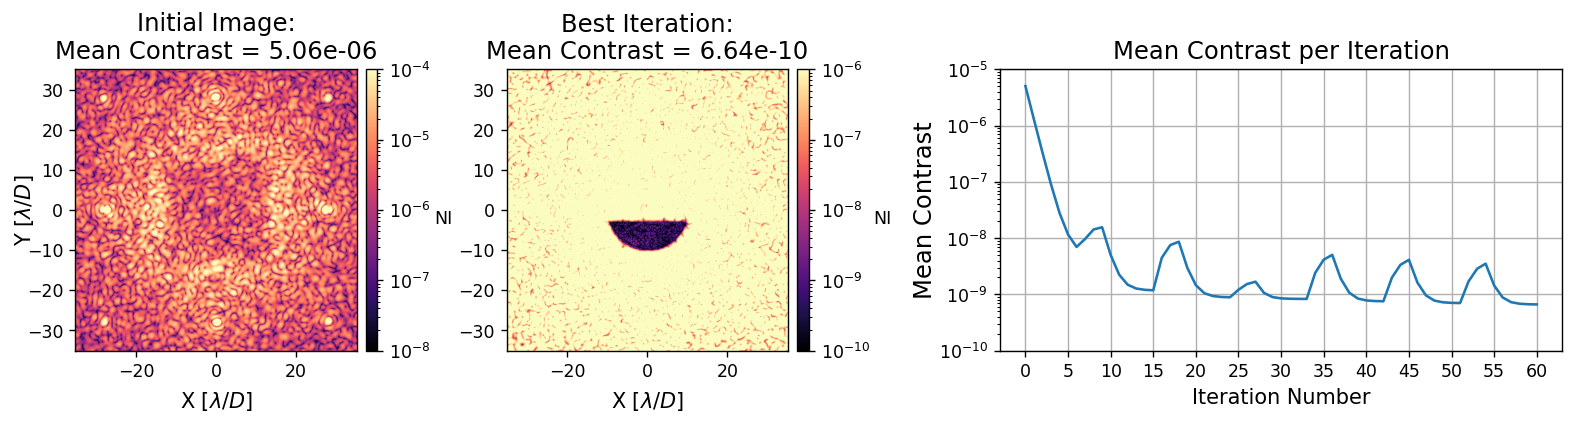

In [31]:
import esc_fresnel.imshows as imshows
reload(imshows)

imshows.plot_data_with_ref(
    efc_data, 
    im1vmin=1e-8, im1vmax=1e-4,
    im2vmin=1e-10, im2vmax=1e-6,
    vmin=1e-10, vmax=1e-5,
    xticks=np.arange(0,60.01,5)
)

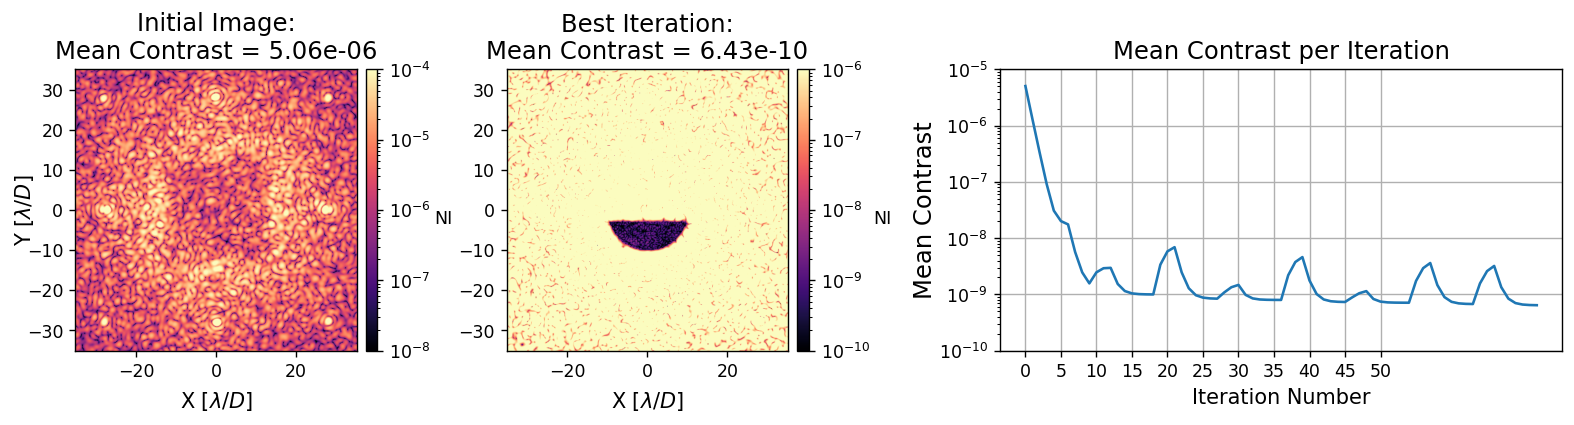

In [33]:
import esc_fresnel.imshows as imshows
reload(imshows)

imshows.plot_data_with_ref(
    efc_data, 
    im1vmin=1e-8, im1vmax=1e-4,
    im2vmin=1e-10, im2vmax=1e-6,
    vmin=1e-10, vmax=1e-5,
    xticks=np.arange(0,50.01,5)
)

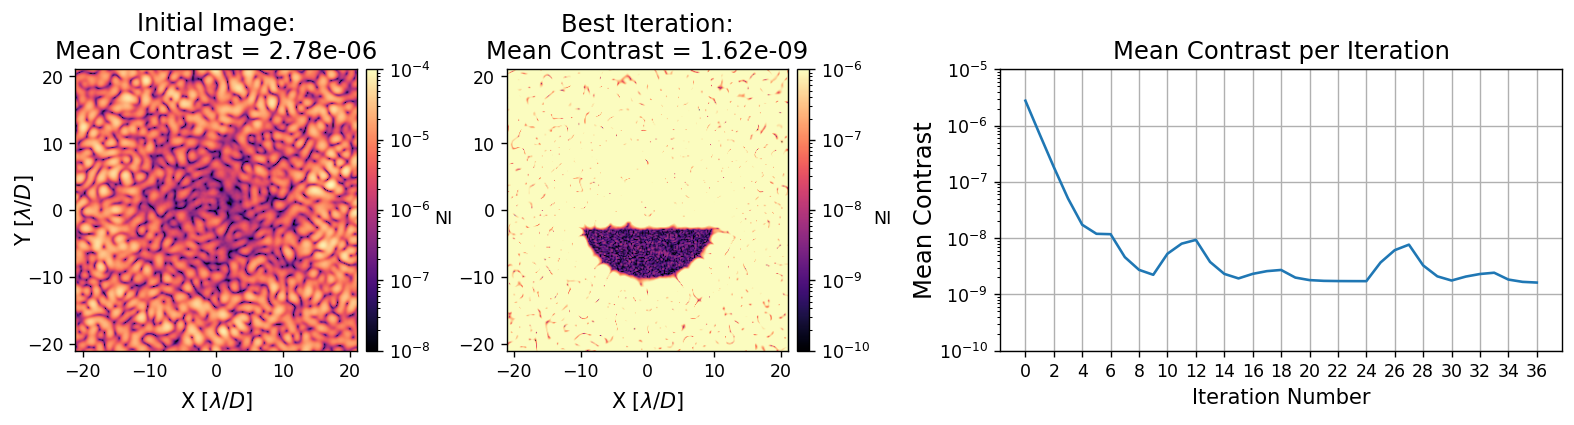

In [ ]:
import esc_fresnel.imshows as imshows
reload(imshows)

imshows.plot_data_with_ref(
    efc_data, 
    im1vmin=1e-8, im1vmax=1e-4,
    im2vmin=1e-10, im2vmax=1e-6,
    vmin=1e-10, vmax=1e-5,
)

In [92]:
wavelength_c = 650e-9*u.m

bw1 = 0.02
Nwaves1 = 5
bp1_waves = np.linspace(wavelength_c*(1-bw1/2), wavelength_c*(1+bw1/2), Nwaves1)

bw2 = 0.05
Nwaves2 = 5
bp2_waves = np.linspace(wavelength_c*(1-bw2/2), wavelength_c*(1+bw2/2), Nwaves2)

bw3 = 0.10
Nwaves3 = 10
bp3_waves = np.linspace(wavelength_c*(1-bw3/2), wavelength_c*(1+bw3/2), Nwaves3)


In [ ]:
bp1_im = 0.0
for i in range(Nwaves1):
    M.wavelength = bp1_waves[i]
    mono_im = M.snap()
    bp1_im += mono_im/Nwaves1
bp1_contrast = xp.mean(bp1_im[coro_mask])

bp2_im = 0.0
for i in range(Nwaves2):
    M.wavelength = bp2_waves[i]
    mono_im = M.snap()
    bp2_im += mono_im/Nwaves2
bp2_contrast = xp.mean(bp2_im[coro_mask])

bp3_im = 0.0
for i in range(Nwaves3):
    M.wavelength = bp3_waves[i]
    mono_im = M.snap()
    bp3_im += mono_im/Nwaves3
bp3_contrast = xp.mean(bp3_im[coro_mask])

1


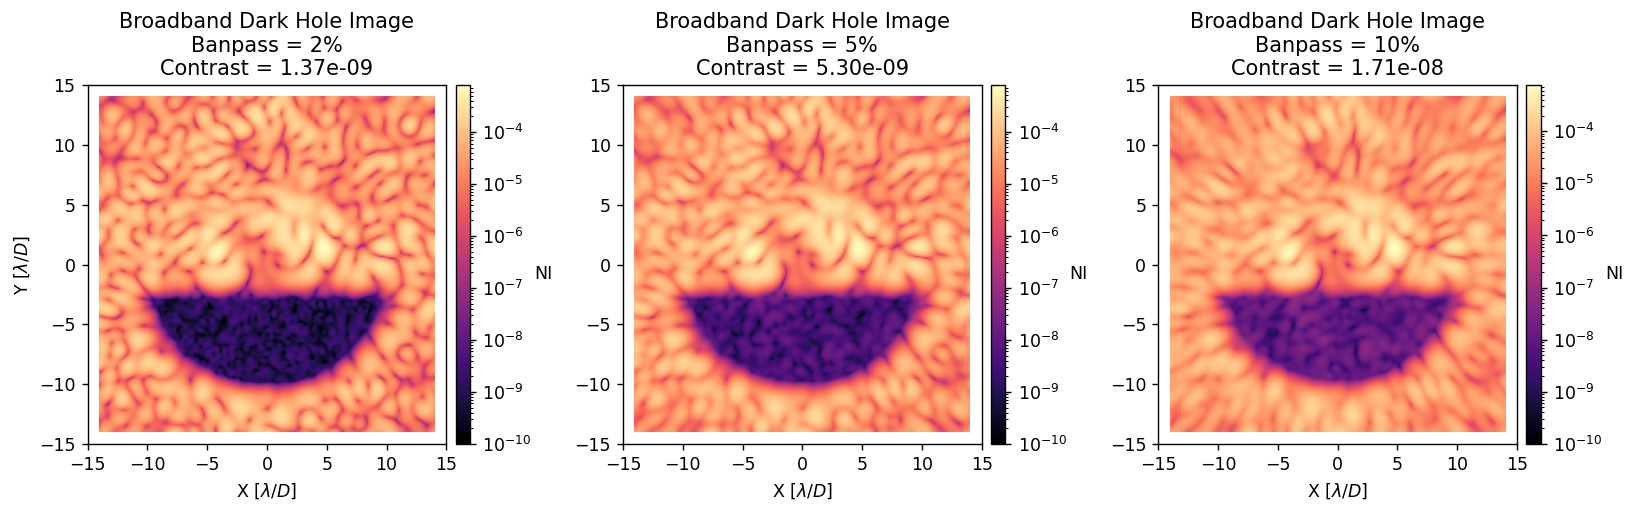

In [ ]:
# ticks = np.arange(-30, 30.01, 10)
ticks = np.arange(-15, 15.01, 5)
imshow(
    [bp1_im, bp2_im, bp3_im],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Broadband Dark Hole Image\nBanpass = {100*bw1:.0f}%\nContrast = {bp1_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw2:.0f}%\nContrast = {bp2_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw3:.0f}%\nContrast = {bp3_contrast:.2e}',],
    title_fzs=[12]*3,
    norms=[LogNorm(vmin=1e-10), LogNorm(vmin=1e-10), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    npix=3*[200],
    xlabels=['X [$\lambda/D$]']*3,
    ylabels=['Y [$\lambda/D$]', None, None],
    xticks=[ticks]*3,
    yticks=[ticks]*3,
    cmaps=['magma']*3,
    cbar_labels=['NI']*3,
    wspace=0.4,
)



1


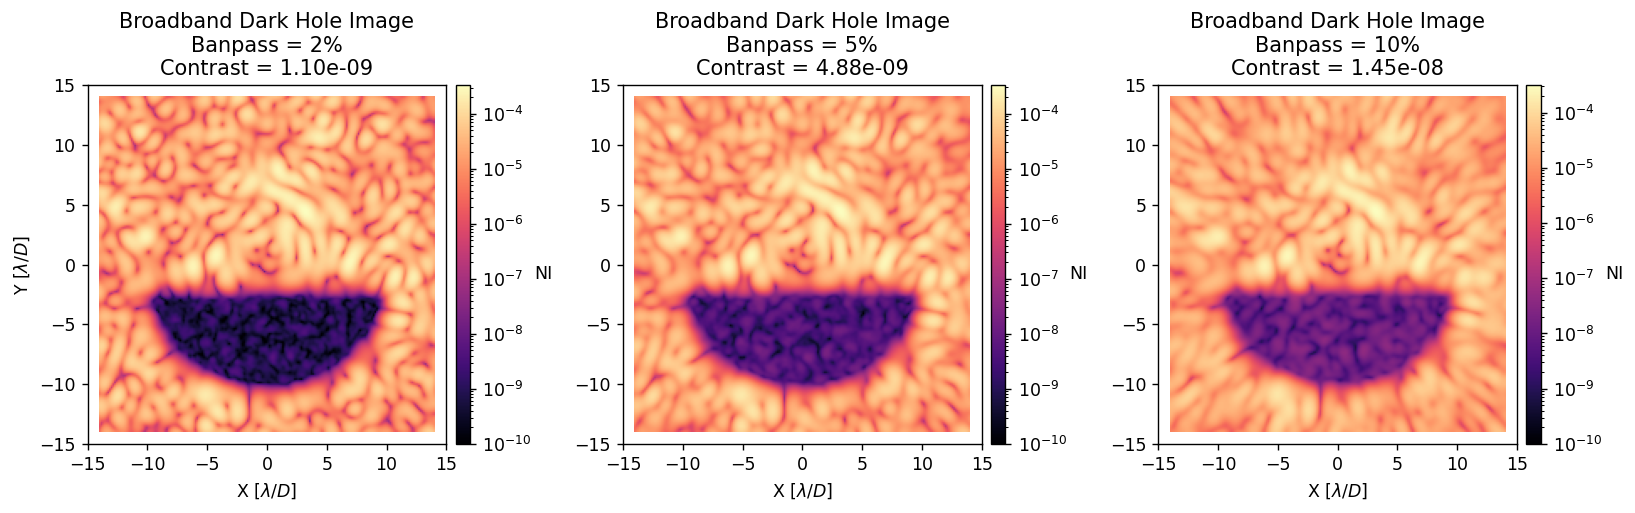

In [94]:
# ticks = np.arange(-30, 30.01, 10)
ticks = np.arange(-15, 15.01, 5)
imshow(
    [bp1_im, bp2_im, bp3_im],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Broadband Dark Hole Image\nBanpass = {100*bw1:.0f}%\nContrast = {bp1_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw2:.0f}%\nContrast = {bp2_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw3:.0f}%\nContrast = {bp3_contrast:.2e}',],
    title_fzs=[12]*3,
    norms=[LogNorm(vmin=1e-10), LogNorm(vmin=1e-10), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    npix=3*[200],
    xlabels=['X [$\lambda/D$]']*3,
    ylabels=['Y [$\lambda/D$]', None, None],
    xticks=[ticks]*3,
    yticks=[ticks]*3,
    cmaps=['magma']*3,
    cbar_labels=['NI']*3,
    wspace=0.4,
)

1


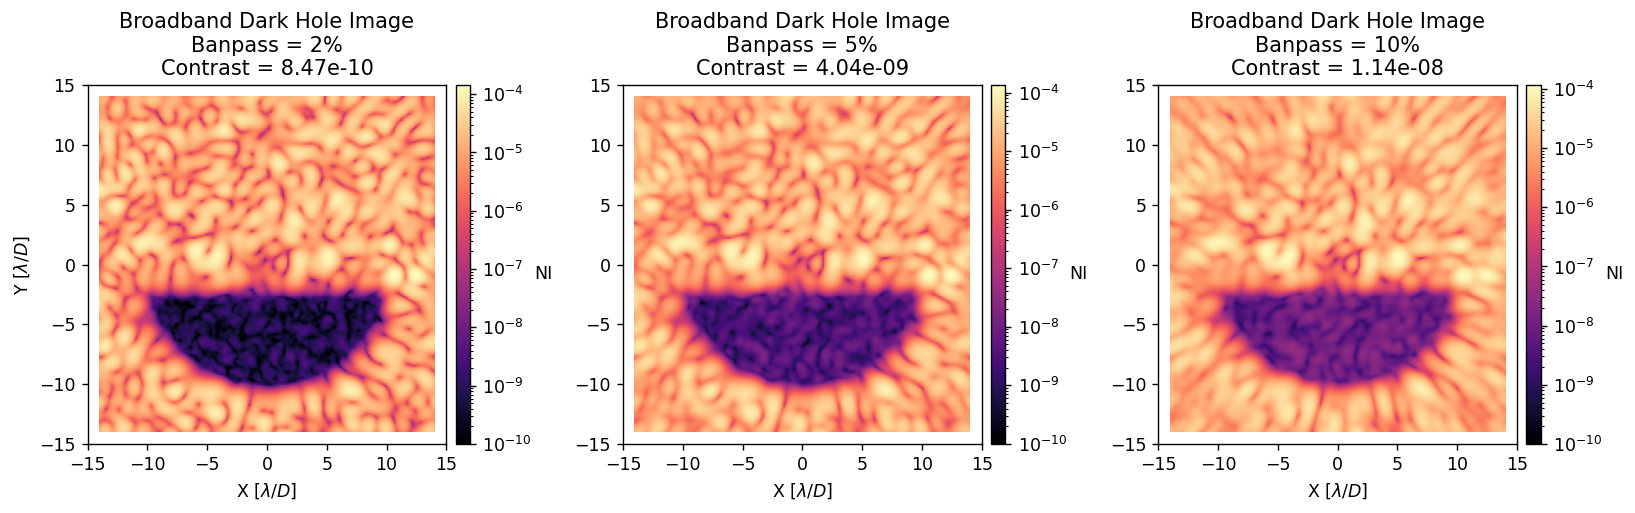

In [35]:
# ticks = np.arange(-30, 30.01, 10)
ticks = np.arange(-15, 15.01, 5)
imshow(
    [bp1_im, bp2_im, bp3_im],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Broadband Dark Hole Image\nBanpass = {100*bw1:.0f}%\nContrast = {bp1_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw2:.0f}%\nContrast = {bp2_contrast:.2e}',
            f'Broadband Dark Hole Image\nBanpass = {100*bw3:.0f}%\nContrast = {bp3_contrast:.2e}',],
    title_fzs=[12]*3,
    norms=[LogNorm(vmin=1e-10), LogNorm(vmin=1e-10), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    npix=3*[200],
    xlabels=['X [$\lambda/D$]']*3,
    ylabels=['Y [$\lambda/D$]', None, None],
    xticks=[ticks]*3,
    yticks=[ticks]*3,
    cmaps=['magma']*3,
    cbar_labels=['NI']*3,
    wspace=0.4,
)